In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

In [129]:
data = pd.read_csv('../datasets/data_compramostucoche.csv')
data.head()

,marca,modelo,version,registration,km,gear_type,fuel_type,power,price
0,Alfa Romeo,Stelvio,2.2 JTDM,12/2021,118875,Automático,Diésel,190,24899
1,Hyundai,Tucson,1.6 T-GDI,12/2022,66838,Manual,Gasolina,150,23799
2,Mazda,CX-30,2.0 e-Skyactiv-X Mild-Hybrid,03/2022,69720,Manual,Gasolina,186,21499
3,Volkswagen,Tiguan,1.5 TSI ACT,08/2020,49789,Automático,Gasolina,150,26899
4,Citroen,C4,1.2 PureTech Mild-Hybrid,03/2025,14335,Automático,Gasolina,136,22299


In [130]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   marca         3400 non-null   str  
 1   modelo        3400 non-null   str  
 2   version       3400 non-null   str  
 3   registration  3400 non-null   str  
 4   km            3400 non-null   int64
 5   gear_type     3400 non-null   str  
 6   fuel_type     3400 non-null   str  
 7   power         3400 non-null   int64
 8   price         3400 non-null   int64
dtypes: int64(3), str(6)
memory usage: 239.2 KB


In [131]:
data.describe()

,km,power,price
count,3400.000000,3400.000000,3400.000000
mean,79463.727647,134.242353,17275.735294
std,39361.407421,43.968550,7225.532712
min,23.000000,60.000000,6499.000000
25%,47780.750000,110.000000,11899.000000
50%,77766.500000,130.000000,15599.000000
75%,109890.500000,150.000000,21099.000000
max,159848.000000,392.000000,49699.000000


In [132]:
data.isnull().sum()

marca           0
modelo          0
version         0
registration    0
km              0
gear_type       0
fuel_type       0
power           0
price           0
dtype: int64

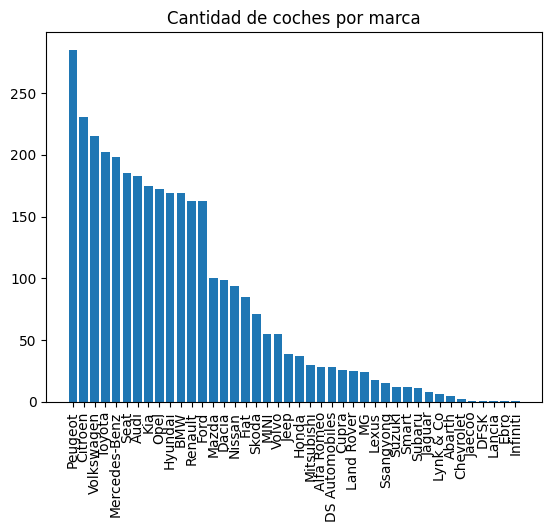

In [133]:
plt.bar(data['marca'].value_counts().index, data['marca'].value_counts().values)
plt.xticks(rotation=90)
plt.title('Cantidad de coches por marca')
plt.show()

In [134]:
print(data['marca'].value_counts())

marca
Peugeot           285
Citroen           231
Volkswagen        215
Toyota            202
Mercedes-Benz     198
Seat              185
Audi              183
Kia               175
Opel              172
Hyundai           169
BMW               169
Renault           163
Ford              163
Mazda             100
Dacia              99
Nissan             94
Fiat               85
Skoda              71
MINI               55
Volvo              55
Jeep               39
Honda              37
Mitsubishi         30
Alfa Romeo         28
DS Automobiles     28
Cupra              26
Land Rover         25
MG                 24
Lexus              18
Ssangyong          15
Suzuki             12
Smart              12
Subaru             11
Jaguar              8
Lynk & Co           6
Abarth              5
Chevrolet           2
Jaecoo              1
DFSK                1
Lancia              1
Ebro                1
Infiniti            1
Name: count, dtype: int64


In [135]:
df_marcas_precio_medio = data.groupby(['marca'])['price'].mean().reset_index()
df_marcas_precio_medio

,marca,price
0,Abarth,19259.000000
1,Alfa Romeo,20520.428571
2,Audi,21392.989071
3,BMW,22166.455621
4,Chevrolet,8799.000000
5,Citroen,11824.541126
6,Cupra,27514.384615
7,DFSK,20599.000000
8,DS Automobiles,17009.714286
9,Dacia,12749.505051


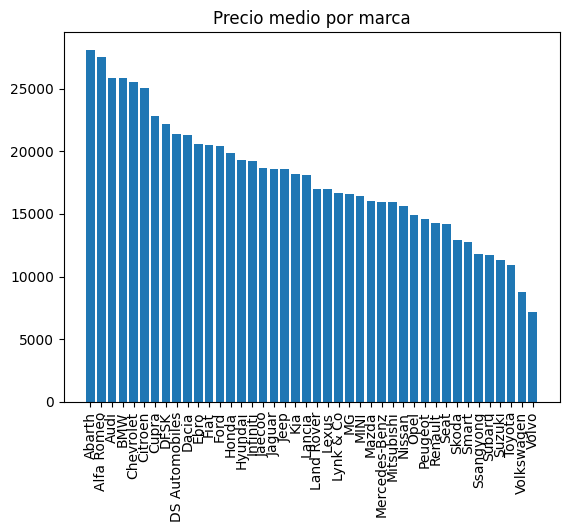

In [136]:
plt.bar(df_marcas_precio_medio['marca'], df_marcas_precio_medio['price'].sort_values(ascending=False))
plt.xticks(rotation=90)
plt.title('Precio medio por marca')
plt.show()

In [137]:
df_marcas_kms_medios = data.groupby(['marca'])['km'].mean().reset_index()

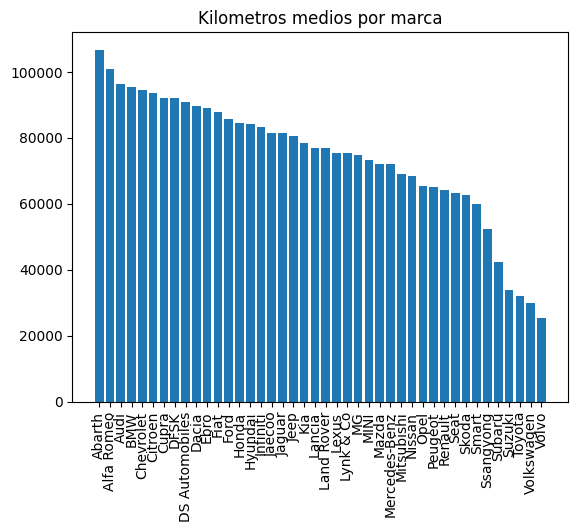

In [138]:
plt.bar(df_marcas_kms_medios['marca'], df_marcas_kms_medios['km'].sort_values(ascending=False))
plt.xticks(rotation=90)
plt.title('Kilometros medios por marca')
plt.show()

In [139]:
data[data['marca'] == 'Abarth']

,marca,modelo,version,registration,km,gear_type,fuel_type,power,price
778,Abarth,595,1.4 Turbo,09/2020,90134,Manual,Gasolina,145,15299
2197,Abarth,695,1.4 Turbo,11/2022,31198,Manual,Gasolina,179,22499
2369,Abarth,500,1.4 Turbo,08/2024,22446,Manual,Gasolina,179,26199
2471,Abarth,595C,1.4,05/2019,100392,Automático,Gasolina,180,16699
2597,Abarth,595,1.4,05/2019,82228,Manual,Gasolina,160,15599


In [140]:
data['registration'] = pd.to_datetime(data['registration'], format='%m/%Y')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   marca         3400 non-null   str           
 1   modelo        3400 non-null   str           
 2   version       3400 non-null   str           
 3   registration  3400 non-null   datetime64[us]
 4   km            3400 non-null   int64         
 5   gear_type     3400 non-null   str           
 6   fuel_type     3400 non-null   str           
 7   power         3400 non-null   int64         
 8   price         3400 non-null   int64         
dtypes: datetime64[us](1), int64(3), str(5)
memory usage: 239.2 KB


In [141]:
df_groupby_model = data.groupby(['modelo', 'marca']).agg({
    'km': 'mean', 
    'power': 'mean', 
    'registration': 'mean', 
    'price': 'mean'
}).reset_index()
df_groupby_model

,modelo,marca,km,power,registration,price
0,01,Lynk & Co,71990.166667,261.000000,2022-11-10 08:00:00,22799.000000
1,108,Citroen,79798.000000,100.000000,2018-04-01 00:00:00,10499.000000
2,108,Mercedes-Benz,159353.000000,195.000000,2019-09-01 00:00:00,26699.000000
3,108,Peugeot,52105.000000,75.111111,2018-04-28 08:00:00,8921.222222
4,2,Citroen,14976.000000,110.000000,2022-12-01 00:00:00,14099.000000
...,...,...,...,...,...,...
520,i40,Hyundai,130029.000000,135.000000,2014-04-01 00:00:00,9199.000000
521,ix20,Hyundai,87584.000000,90.000000,2016-02-01 00:00:00,8199.000000
522,ix35,Hyundai,135166.000000,115.000000,2014-11-01 00:00:00,10799.000000
523,pro_cee'd,Kia,119125.000000,136.666667,2018-05-12 16:00:00,13699.000000


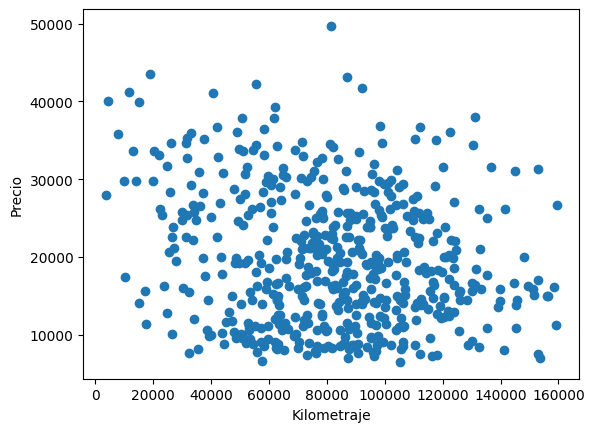

In [142]:
plt.scatter(x=df_groupby_model['km'], y=df_groupby_model['price'])
plt.xlabel('Kilometraje')
plt.ylabel('Precio')
plt.show()

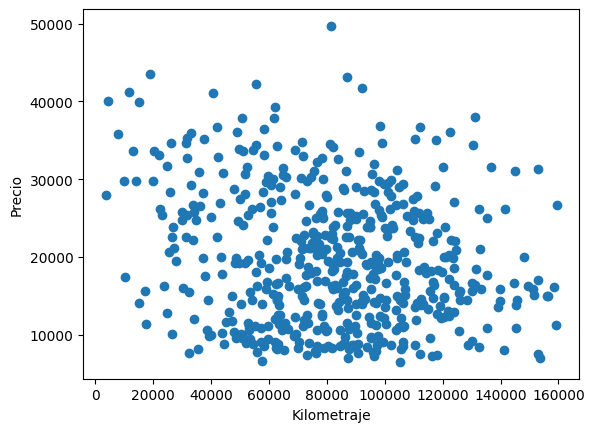

In [143]:
plt.scatter(x=df_groupby_model['km'], y=df_groupby_model['price'])
plt.xlabel('Kilometraje')
plt.ylabel('Precio')
plt.show()

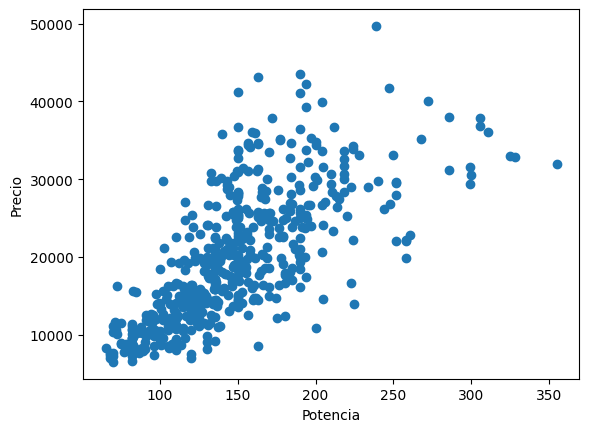

In [144]:
plt.scatter(x=df_groupby_model['power'], y=df_groupby_model['price'])
plt.xlabel('Potencia')
plt.ylabel('Precio')
plt.show()

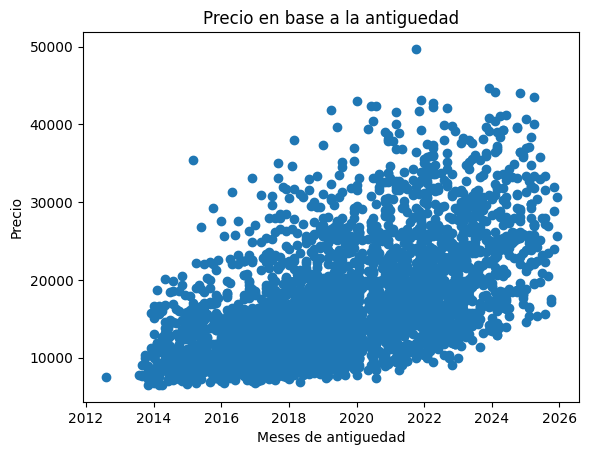

In [145]:
plt.scatter(x=data['registration'], y=data['price'])
plt.title('Precio en base a la antiguedad')
plt.xlabel('Meses de antiguedad')
plt.ylabel('Precio')
plt.show()

In [146]:
# Transformamos las columnas categoricas
data['model_unique'] = data['marca'] + "_" + data['modelo']
data['version_unique'] = data['model_unique'] + "_" + data['version']

le = LabelEncoder()
data['make_num'] = le.fit_transform(data['marca'])
data['model_num'] = le.fit_transform(data['model_unique'])
data['version_num'] = le.fit_transform(data['version_unique'])

oe = OneHotEncoder()
cols_to_encode = ['gear_type', 'fuel_type']

encoded_array = oe.fit_transform(data[cols_to_encode]).toarray() 

df_encoded = pd.DataFrame(
    encoded_array, 
    columns=oe.get_feature_names_out(cols_to_encode),
    index=data.index
)

df_final = pd.concat([data, df_encoded], axis=1)

cols_to_drop = [
    'marca', 'modelo', 'version', 'fuel_type', 'gear_type', 
    'model_unique', 'version_unique'
]

hoy = pd.Timestamp.now()
df_final['antiguedad_meses'] = ((hoy.year - data['registration'].dt.year) * 12 + 
                          (hoy.month - data['registration'].dt.month))

# Eliminamos la columna original de fecha porque el modelo no la entiende
df_final = df_final.drop(columns=['registration'])

df_final.drop(cols_to_drop, axis=1, inplace=True)

In [147]:
df_final.head()

,km,power,price,make_num,model_num,version_num,gear_type_Automático,gear_type_Doble embrague,gear_type_Manual,fuel_type_Diésel,fuel_type_Gasolina,fuel_type_Híbrido,antiguedad_meses
0,118875,190,24899,1,7,13,1.0,0.0,0.0,1.0,0.0,0.0,51
1,66838,150,23799,14,222,482,0.0,0.0,1.0,0.0,1.0,0.0,39
2,69720,186,21499,26,275,639,0.0,0.0,1.0,0.0,1.0,0.0,48
3,49789,150,26899,40,509,1245,1.0,0.0,0.0,0.0,1.0,0.0,67
4,14335,136,22299,5,113,267,1.0,0.0,0.0,0.0,1.0,0.0,12


Text(0.5, 1.0, 'Outliers de Kilómetros')

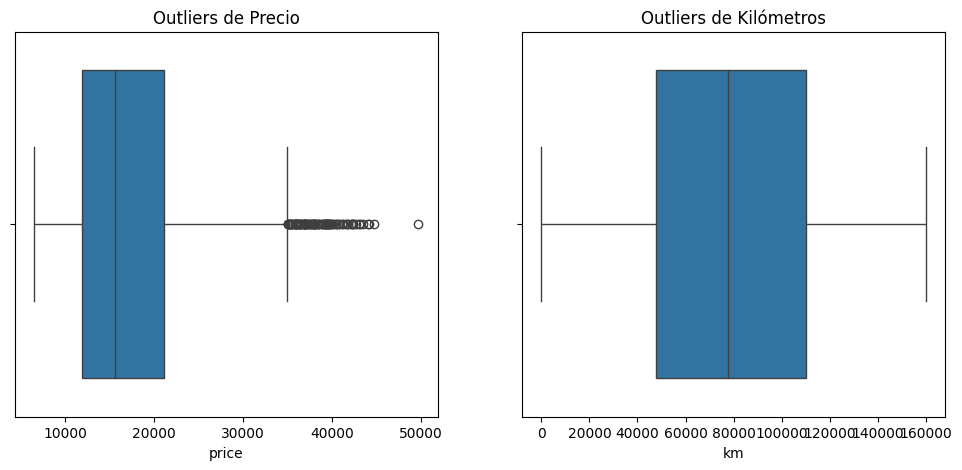

In [148]:
plt.figure(figsize=(12, 5))

# Gráfico para Precio
plt.subplot(1, 2, 1)
sns.boxplot(x=data['price'])
plt.title('Outliers de Precio')

# Gráfico para KM
plt.subplot(1, 2, 2)
sns.boxplot(x=data['km'])
plt.title('Outliers de Kilómetros')

In [149]:
print(df_final[df_final['price'] > 35000]['price'].count())
total_outliers = len(df_final[df_final['price'] > 34000])
porcentaje = (total_outliers / len(df_final)) * 100
print(f"Porcentaje de outliers en price: {porcentaje}")

86
Porcentaje de outliers en price: 3.058823529411765


In [150]:
df_final = df_final[df_final['price'] <= 32500]

Text(0.5, 1.0, 'Outliers de Precio')

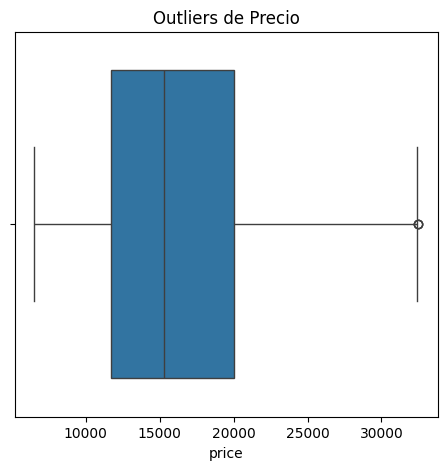

In [151]:
plt.figure(figsize=(12, 5))

# Gráfico para Precio
plt.subplot(1, 2, 1)
sns.boxplot(x=df_final['price'])
plt.title('Outliers de Precio')

In [158]:
df_final.to_csv('../datasets/coches_clean.csv', index=False)

In [153]:
X = df_final.drop(columns='price')
y = df_final['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [154]:
X.info()

<class 'pandas.DataFrame'>
Index: 3252 entries, 0 to 3399
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   km                        3252 non-null   int64  
 1   power                     3252 non-null   int64  
 2   make_num                  3252 non-null   int64  
 3   model_num                 3252 non-null   int64  
 4   version_num               3252 non-null   int64  
 5   gear_type_Automático      3252 non-null   float64
 6   gear_type_Doble embrague  3252 non-null   float64
 7   gear_type_Manual          3252 non-null   float64
 8   fuel_type_Diésel          3252 non-null   float64
 9   fuel_type_Gasolina        3252 non-null   float64
 10  fuel_type_Híbrido         3252 non-null   float64
 11  antiguedad_meses          3252 non-null   int32  
dtypes: float64(6), int32(1), int64(5)
memory usage: 317.6 KB


In [155]:
model = RandomForestRegressor(n_estimators=250, max_depth=25, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [156]:
predict = model.predict(X_test)

mae = mean_absolute_error(y_test, predict)
r2 = r2_score(y_test, predict)

print(f"MAE: {mae}")
print(f"R2: {r2}")

MAE: 1647.2683212639895
R2: 0.8531491115436405


In [157]:
error_relativo = (mae / df_final['price'].mean()) * 100

print(f"Error relativo: {error_relativo}")

Error relativo: 10.045873395402232
